# Eksplorasi Analisis & Prediksi Harga Pangan dengan Long Short-Term Memory (LSTM)
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi **LSTM (Long Short-Term Memory)** untuk data harga pangan nasional berdasarkan data dari Bank Indonesia.

LSTM adalah jenis *Recurrent Neural Network* (RNN) yang sangat direkomendasikan untuk data harga pangan karena kemampuannya "mengingat" pola jangka panjang dan jangka pendek secara bersamaan.

### Alur Pengerjaan:
1. **Data Collecting**: Memuat data harga dari file `commodity_history.json` (data dari API Bank Indonesia) untuk 10 kategori komoditas pangan dengan rentang tanggal **01-01-2024 hingga 24-05-2026**.
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual dan statistik, serta melakukan Dickey-Fuller Test.
3. **Data Preprocessing**: Melakukan imputasi nilai yang hilang, konversi format data, dan pembuatan fitur-fitur lag & rolling. Dilanjutkan dengan normalisasi data dan pembentukan sekuens (*time steps*) untuk input LSTM.
4. **Model Training (LSTM)**: Melatih model LSTM untuk memprediksi harga secara langsung menggunakan arsitektur *Stacked LSTM* dengan *Dropout regularization*.
5. **Model Evaluation**: Mengevaluasi hasil prediksi menggunakan metrik visual dan statistik (MAE, RMSE, MAPE, R²).


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import warnings

# Menyembunyikan warning Deprecation
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Data Collecting
Data harian diambil dari portal Pusat Informasi Harga Pangan Strategis (PIHPS) Bank Indonesia untuk 10 kategori bahan pokok berikut:
- Beras
- Daging Ayam
- Daging Sapi
- Telur Ayam
- Bawang Merah
- Bawang Putih
- Cabai Merah
- Cabai Rawit
- Minyak Goreng
- Gula Pasir

Rentang waktu yang digunakan adalah **01-01-2024 hingga 24-05-2026**. Data dimuat dari file `commodity_history.json` yang sudah tersedia secara lokal.


In [13]:
# Memuat data dari file JSON lokal atau cache CSV
categories = {
    "cat_1": "Beras",
    "cat_2": "Daging Ayam",
    "cat_3": "Daging Sapi",
    "cat_4": "Telur Ayam",
    "cat_5": "Bawang Merah",
    "cat_6": "Bawang Putih",
    "cat_7": "Cabai Merah",
    "cat_8": "Cabai Rawit",
    "cat_9": "Minyak Goreng",
    "cat_10": "Gula Pasir"
}

json_path = "dataset/commodity_history.json"
cache_file = "raw_market_prices_subcategory_cache.csv"

if os.path.exists(cache_file):
    print(f"Menemukan file cache lokal '{cache_file}'. Membaca data cache...")
    df_raw = pd.read_csv(cache_file)
else:
    import json
    print(f"Membaca data dari local dataset '{json_path}'...")
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File dataset tidak ditemukan di: {json_path}")
        
    with open(json_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)
        
    raw_data_list = []
    
    current_category = None
    # Filter dan strukturkan data agar sesuai format wide dataframe sebelumnya
    for item in json_data["data"]:
        level = item.get("level")
        name = item.get("name")
        if level == 1:
            current_category = name
        elif level == 2:
            if current_category in categories.values():
                row_dict = {"Category": current_category, "Subcategory": name}
                
                # Ambil semua data tanggal (key format DD/MM/YYYY)
                for key, value in item.items():
                    if "/" in key and len(key.split("/")) == 3:
                        row_dict[key] = value
                        
                raw_data_list.append(row_dict)
                print(f"Berhasil memuat data untuk subkategori: {name} (Kategori: {current_category})")
            
    df_raw = pd.DataFrame(raw_data_list)
    
    if not df_raw.empty:
        df_raw.to_csv(cache_file, index=False)
        print(f"Sukses menyimpan data ke cache file '{cache_file}'.")
    else:
        raise ValueError("Gagal memperoleh data dari dataset JSON. Periksa format data.")

start_date = '2024-01-01'
end_date = '2026-05-24'

print("\nDimensi data mentah:", df_raw.shape)
df_raw.head()

Menemukan file cache lokal 'raw_market_prices_subcategory_cache.csv'. Membaca data cache...

Dimensi data mentah: (21, 877)


,Category,Subcategory,01/01/2024,02/01/2024,03/01/2024,04/01/2024,05/01/2024,06/01/2024,07/01/2024,08/01/2024,...,15/05/2026,16/05/2026,17/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026,23/05/2026,24/05/2026
0,Beras,Beras Kualitas Bawah I,"13,550","13,650","13,650","13,650","13,650","13,650","13,650","13,650",...,"14,550","14,100","14,100","14,550","14,550","14,550","14,600","14,600","14,100","14,100"
1,Beras,Beras Kualitas Bawah II,"13,200","13,400","13,400","13,400","13,400","13,400","13,400","13,400",...,"14,550","14,600","14,600","14,550","14,550","14,450","14,450","14,450","14,600","14,600"
2,Beras,Beras Kualitas Medium I,"14,650","14,750","14,750","14,750","14,750","14,750","14,750","14,750",...,"16,150","15,750","15,750","16,150","16,150","16,150","16,150","16,150","15,750","15,750"
3,Beras,Beras Kualitas Medium II,"14,400","14,550","14,600","14,600","14,550","14,550","14,550","14,600",...,"16,000","15,450","15,450","16,000","16,000","16,000","16,000","16,000","15,450","15,450"
4,Beras,Beras Kualitas Super I,"15,850","16,050","16,050","16,050","16,050","16,050","16,050","16,050",...,"17,400","16,850","16,850","17,400","17,400","17,400","17,450","17,450","16,850","16,850"


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (wide format) menjadi format panjang (long format/tidy data) agar mudah dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari 10 komoditas pangan untuk melihat pergerakannya dari **2024 hingga 2026**.
4. Melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test** untuk komoditas utama (Beras).


In [14]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row["Category"]
    subcategory = row["Subcategory"]

    for col in df_raw.columns:
        if "/" in col:
            val_str = str(row[col]).strip()
            if val_str and val_str not in ["-", "null", "None", "nan"]:
                try:
                    price = float(val_str.replace(",", ""))
                    date_val = datetime.strptime(col, "%d/%m/%Y").date()
                    long_data.append({
                        "Date": date_val,
                        "Category": category,
                        "Subcategory": subcategory,
                        "Price": price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy["Date"] = pd.to_datetime(df_tidy["Date"])
df_tidy = df_tidy.sort_values(by=["Category", "Subcategory", "Date"]).reset_index(drop=True)

print("Dimensi data bersih:", df_tidy.shape)
print("\nStatistik Deskriptif Subkategori:")
print(df_tidy.groupby(["Category", "Subcategory"])["Price"].describe())

Dimensi data bersih: (18375, 4)

Statistik Deskriptif Subkategori:
                                               count           mean  \
Category      Subcategory                                             
Bawang Merah  Bawang Merah Ukuran Sedang       875.0   42839.828571   
Bawang Putih  Bawang Putih Ukuran Sedang       875.0   42381.942857   
Beras         Beras Kualitas Bawah I           875.0   14263.028571   
              Beras Kualitas Bawah II          875.0   14096.685714   
              Beras Kualitas Medium I          875.0   15621.485714   
              Beras Kualitas Medium II         875.0   15480.000000   
              Beras Kualitas Super I           875.0   16918.228571   
              Beras Kualitas Super II          875.0   16437.828571   
Cabai Merah   Cabai Merah Besar                875.0   51157.542857   
              Cabai Merah Keriting             875.0   51412.171429   
Cabai Rawit   Cabai Rawit Hijau                875.0   49954.857143   
          

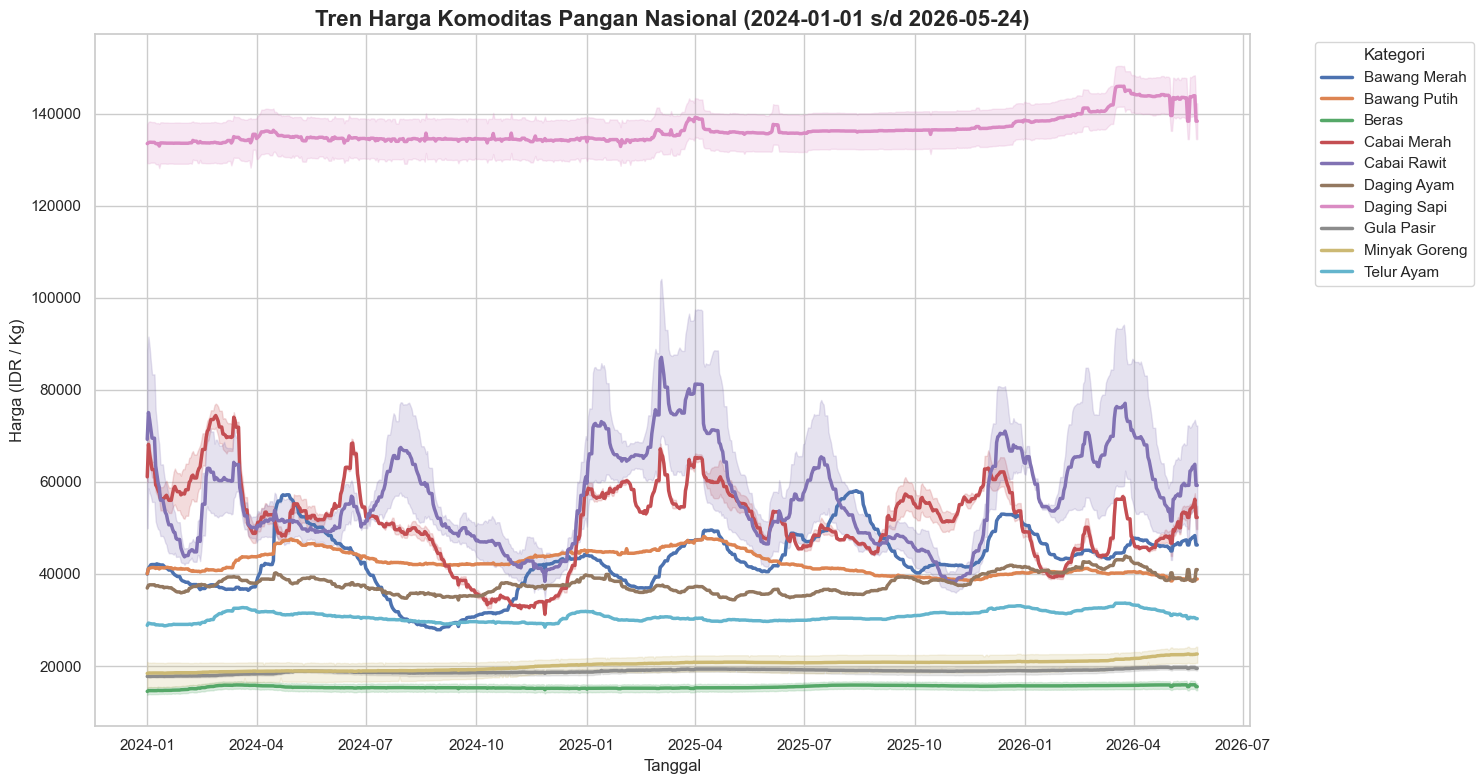

In [15]:
# Plot tren harga untuk seluruh kategori komoditas
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_tidy, x='Date', y='Price', hue='Category', linewidth=2.5)
plt.title(f'Tren Harga Komoditas Pangan Nasional ({start_date} s/d {end_date})', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (IDR / Kg)', fontsize=12)
plt.legend(title='Kategori', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [16]:
# Uji Dickey-Fuller Stasioneritas untuk Seluruh Subkategori
adf_results = []

for subcat_name in df_tidy["Subcategory"].unique():
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    # Imputasi sementara untuk uji ADF (jika ada nilai kosong)
    price_series = df_subcat["Price"].interpolate(method='linear').ffill().bfill()
    
    result = adfuller(price_series)
    adf_results.append({
        "Category": df_subcat["Category"].iloc[0] if not df_subcat.empty else "",
        "Subcategory": subcat_name,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Is Stationary": "Stasioner" if result[1] < 0.05 else "TIDAK Stasioner"
    })

df_adf_summary = pd.DataFrame(adf_results)
print("Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:")
df_adf_summary

Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:


,Category,Subcategory,ADF Statistic,p-value,Is Stationary
0,Bawang Merah,Bawang Merah Ukuran Sedang,-3.4297,0.0100,Stasioner
1,Bawang Putih,Bawang Putih Ukuran Sedang,-1.7349,0.4132,TIDAK Stasioner
2,Beras,Beras Kualitas Bawah I,-3.5541,0.0067,Stasioner
3,Beras,Beras Kualitas Bawah II,-2.6118,0.0906,TIDAK Stasioner
4,Beras,Beras Kualitas Medium I,-3.1120,0.0257,Stasioner
5,Beras,Beras Kualitas Medium II,-3.3318,0.0135,Stasioner
6,Beras,Beras Kualitas Super I,-3.8322,0.0026,Stasioner
7,Beras,Beras Kualitas Super II,-3.9669,0.0016,Stasioner
8,Cabai Merah,Cabai Merah Besar,-2.5208,0.1105,TIDAK Stasioner
9,Cabai Merah,Cabai Merah Keriting,-3.4356,0.0098,Stasioner


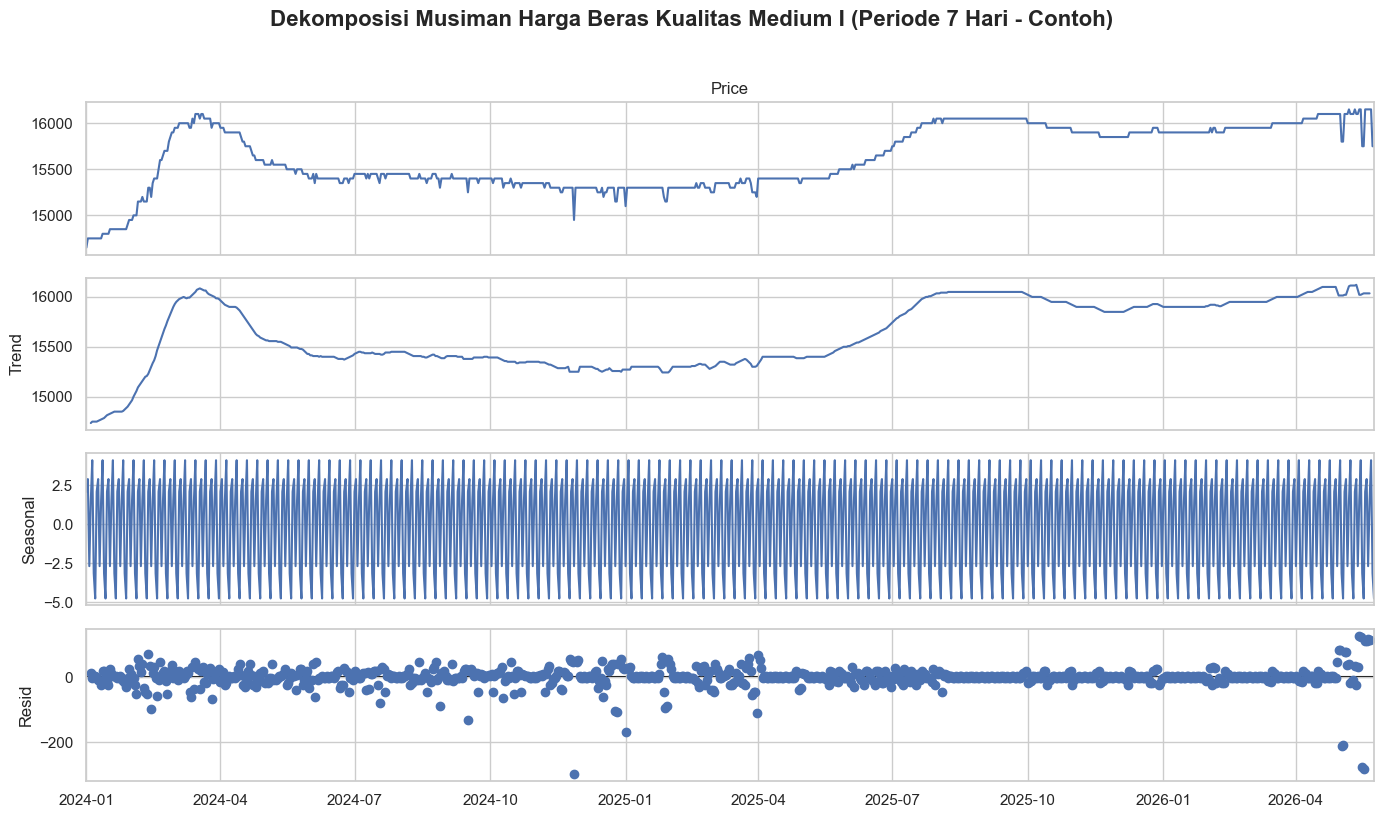

In [17]:
# Dekomposisi Musiman Harga Beras Kualitas Medium I (sebagai contoh visualisasi tren & musiman)
df_beras_demo = df_tidy[df_tidy["Subcategory"] == "Beras Kualitas Medium I"].copy()
df_beras_demo = df_beras_demo.set_index("Date").asfreq('D')
df_beras_demo["Price"] = df_beras_demo["Price"].interpolate(method='linear').ffill().bfill()

decomposition = seasonal_decompose(df_beras_demo["Price"], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Dekomposisi Musiman Harga Beras Kualitas Medium I (Periode 7 Hari - Contoh)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Modeling Functions
Sebelum melatih model LSTM pada ke-21 subkategori komoditas pangan, kita mempersiapkan fungsi preprocessing dan pembuatan model yang handal dan bebas kebocoran data (*data leakage*):
1. **Log-Transformation**: Mengurangi ketimpangan varians (volatilitas tinggi seperti pada Cabai) serta mencegah prediksi harga negatif di backend dengan melakukan transformasi logaritma natural (`np.log1p`) pada harga pangan sebelum fitting/scaling.
2. **Pembuatan Fitur Temporal & Lag**: Menghitung hari dalam seminggu, tanggal, bulan, tahun, akhir pekan, serta lag harga (t-1, t-2, t-7) dan statistik bergulir (rata-rata dan standar deviasi bergulir 7 hari dari lag_1 untuk mencegah leakage).
3. **Skalasi Data Temporal Independen**: MinMaxScaler dilatih (*fit*) hanya pada training set (80% data awal), lalu digunakan untuk mentransformasi training set dan test set secara terpisah.
4. **Pembentukan Windowed Sequences**: Memformat data menjadi bentuk sequence historical 7 hari `[samples, time_steps, features]` yang dibutuhkan sebagai dimensi input LSTM.
5. **Arsitektur Stacked LSTM dengan PyTorch (Best Practices)**: Model deep learning LSTM yang terdiri dari Stacked LSTM layers (64 unit dan 32 unit) dengan Xavier/Orthogonal parameter initialization, Dropout 20% untuk regularisasi, learning rate scheduler (ReduceLROnPlateau), gradient clipping untuk stabilitas numerik, dan early stopping (patience=10) berdasarkan validation loss.

In [18]:
def preprocess_series(df_series):
    df = df_series.copy()
    df = df.asfreq('D')
    df['Price'] = df['Price'].interpolate(method='linear').ffill().bfill()
    df['Price_log'] = np.log1p(df['Price'])

    # Fitur Kalender
    df['day_of_week'] = df.index.dayofweek
    df['day_of_month'] = df.index.day
    df['day_of_year'] = df.index.dayofyear
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # Fitur Lag (berdasarkan log price)
    df['lag_1'] = df['Price_log'].shift(1)
    df['lag_2'] = df['Price_log'].shift(2)
    df['lag_7'] = df['Price_log'].shift(7)

    # Fitur Rolling (berdasarkan lag_1 untuk mencegah leakage)
    df['rolling_mean_7'] = df['lag_1'].rolling(window=7).mean()
    df['rolling_std_7'] = df['lag_1'].rolling(window=7).std()

    df = df.dropna()
    return df

# Fungsi untuk membuat sequences (windowed data)
def create_sequences(X, y, time_steps=7):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

# Definisi Model Stacked LSTM PyTorch dengan Best Practices
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size1=64, hidden_size2=32, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm1 = nn.LSTM(input_size, hidden_size1, batch_first=True)
        self.dropout1 = nn.Dropout(dropout)
        self.lstm2 = nn.LSTM(hidden_size1, hidden_size2, batch_first=True)
        self.dropout2 = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size2, 1)
        self.apply(self._init_weights)
        
    def forward(self, x):
        out, _ = self.lstm1(x)
        out = self.dropout1(out)
        out, _ = self.lstm2(out)
        out = self.dropout2(out)
        out = self.fc(out[:, -1, :])
        return out
        
    def _init_weights(self, m):
        if isinstance(m, nn.LSTM):
            for name, param in m.named_parameters():
                if 'weight_ih' in name:
                    nn.init.xavier_uniform_(param.data)
                elif 'weight_hh' in name:
                    nn.init.orthogonal_(param.data)
                elif 'bias' in name:
                    param.data.fill_(0.0)
        elif isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight.data)
            if m.bias is not None:
                m.bias.data.fill_(0.0)

# Fungsi Training PyTorch LSTM dengan LRScheduler & Early Stopping
def train_pytorch_lstm(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=16, patience=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
    
    X_val_t = torch.tensor(X_val, dtype=torch.float32)
    y_val_t = torch.tensor(y_val, dtype=torch.float32)
    
    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0
    
    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
        # Evaluasi Validasi untuk Early Stopping & Scheduler
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_t)
            val_loss = criterion(val_outputs, y_val_t).item()
            
        scheduler.step(val_loss)
            
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
                
    if best_weights is not None:
        model.load_state_dict(best_weights)
    return model

def predict_pytorch_lstm(model, X_test):
    model.eval()
    with torch.no_grad():
        X_test_t = torch.tensor(X_test, dtype=torch.float32)
        preds = model(X_test_t).numpy()
    return preds

def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2 Score": r2}

In [19]:
# Eksekusi Loop Pelatihan Model LSTM PyTorch untuk Seluruh Subkategori
all_metrics = []
predictions_dict = {}

subcategories = df_tidy["Subcategory"].unique()
features = ['day_of_week', 'day_of_month', 'day_of_year', 'month', 'is_weekend',
            'lag_1', 'lag_2', 'lag_7', 'rolling_mean_7', 'rolling_std_7']
time_steps = 7

# Set Seed untuk Reproduksibilitas & Determinisme
import random
random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True

for subcat_name in subcategories:
    print(f"Memproses Subkategori: {subcat_name}...")
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    if df_subcat.empty:
        print(f"  Peringatan: Data untuk {subcat_name} tidak ditemukan.")
        continue
        
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    
    # 1. Preprocess (dengan Log-transformation)
    df_prep = preprocess_series(df_subcat)
    
    # 2. Split
    split_idx = int(len(df_prep) * 0.8)
    df_train = df_prep.iloc[:split_idx].copy()
    df_test = df_prep.iloc[split_idx:].copy()
    
    # 3. Scale (MinMaxScaler pada log price)
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    
    X_train_scaled = scaler_X.fit_transform(df_train[features])
    X_test_scaled = scaler_X.transform(df_test[features])
    
    y_train_scaled = scaler_y.fit_transform(df_train[['Price_log']])
    y_test_scaled = scaler_y.transform(df_test[['Price_log']])
    
    # 4. Sequences
    X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_steps)
    X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, time_steps)
    
    # Split validation_fit (10% training data) secara temporal
    val_size = int(len(X_train_seq) * 0.1)
    if val_size == 0:
        val_size = 1
    X_train_fit, X_val_fit = X_train_seq[:-val_size], X_train_seq[-val_size:]
    y_train_fit, y_val_fit = y_train_seq[:-val_size], y_train_seq[-val_size:]
    
    # 5. Build & Train
    model = LSTMModel(input_size=len(features), hidden_size1=64, hidden_size2=32, dropout=0.2)
    model = train_pytorch_lstm(
        model, X_train_fit, y_train_fit, X_val_fit, y_val_fit,
        epochs=50, batch_size=16, patience=10
    )
    
    # 6. Predict
    y_pred_scaled = predict_pytorch_lstm(model, X_test_seq)
    y_pred_log = scaler_y.inverse_transform(y_pred_scaled).flatten()
    # Konversi balik dari log scale ke Rupiah asli
    y_pred_orig = np.expm1(y_pred_log)
    
    # Ambil data aktual yang sesuai
    df_test_eval = df_test.iloc[time_steps:].copy()
    df_test_eval['LSTM_Prediction'] = y_pred_orig
    predictions_dict[subcat_name] = df_test_eval
    
    # 7. Evaluate
    metrics = evaluate_predictions(df_test_eval['Price'], df_test_eval['LSTM_Prediction'])
    
    all_metrics.append({
        "Subcategory": subcat_name,
        "MAE": round(metrics["MAE"], 4),
        "RMSE": round(metrics["RMSE"], 4),
        "MAPE (%)": round(metrics["MAPE (%)"], 4),
        "R2 Score": round(metrics["R2 Score"], 4)
    })
    print(f"  MAE: {metrics['MAE']:.2f} | RMSE: {metrics['RMSE']:.2f} | MAPE: {metrics['MAPE (%)']:.4f}% | R2: {metrics['R2 Score']:.4f}")

df_all_metrics = pd.DataFrame(all_metrics)
print("\nProses modeling selesai untuk seluruh subkategori.")

Memproses Subkategori: Bawang Merah Ukuran Sedang...
  MAE: 589.79 | RMSE: 750.79 | MAPE: 1.2523% | R2: 0.9312
Memproses Subkategori: Bawang Putih Ukuran Sedang...
  MAE: 511.78 | RMSE: 592.62 | MAPE: 1.2837% | R2: 0.0730
Memproses Subkategori: Beras Kualitas Bawah I...
  MAE: 46.99 | RMSE: 89.88 | MAPE: 0.3265% | R2: 0.0004
Memproses Subkategori: Beras Kualitas Bawah II...
  MAE: 24.23 | RMSE: 33.32 | MAPE: 0.1674% | R2: 0.7992
Memproses Subkategori: Beras Kualitas Medium I...
  MAE: 48.36 | RMSE: 75.15 | MAPE: 0.3030% | R2: 0.2916
Memproses Subkategori: Beras Kualitas Medium II...
  MAE: 65.76 | RMSE: 109.23 | MAPE: 0.4172% | R2: -0.0162
Memproses Subkategori: Beras Kualitas Super I...
  MAE: 48.91 | RMSE: 106.44 | MAPE: 0.2860% | R2: 0.2455
Memproses Subkategori: Beras Kualitas Super II...
  MAE: 114.20 | RMSE: 148.44 | MAPE: 0.6813% | R2: -0.5499
Memproses Subkategori: Cabai Merah Besar...
  MAE: 2871.10 | RMSE: 3539.12 | MAPE: 6.1256% | R2: 0.5975
Memproses Subkategori: Cabai Mera

## 4. Model Evaluation & Comparison
Bagian ini menyajikan performa model **LSTM** untuk ke-21 subkategori komoditas pangan berdasarkan metrik statistik (MAE, RMSE, MAPE, dan R2 Score) pada data pengujian.

In [20]:
# Menampilkan Ringkasan Evaluasi Seluruh Subkategori menggunakan LSTM
df_summary = df_all_metrics.set_index("Subcategory")
pd.set_option('display.max_columns', None)
df_summary

,MAE,RMSE,MAPE (%),R2 Score
Subcategory,,,,
Bawang Merah Ukuran Sedang,589.7870,750.7886,1.2523,0.9312
Bawang Putih Ukuran Sedang,511.7843,592.6195,1.2837,0.0730
Beras Kualitas Bawah I,46.9926,89.8761,0.3265,0.0004
Beras Kualitas Bawah II,24.2306,33.3154,0.1674,0.7992
Beras Kualitas Medium I,48.3567,75.1489,0.3030,0.2916
Beras Kualitas Medium II,65.7560,109.2292,0.4172,-0.0162
Beras Kualitas Super I,48.9055,106.4436,0.2860,0.2455
Beras Kualitas Super II,114.1962,148.4437,0.6813,-0.5499
Cabai Merah Besar,2871.0975,3539.1151,6.1256,0.5975


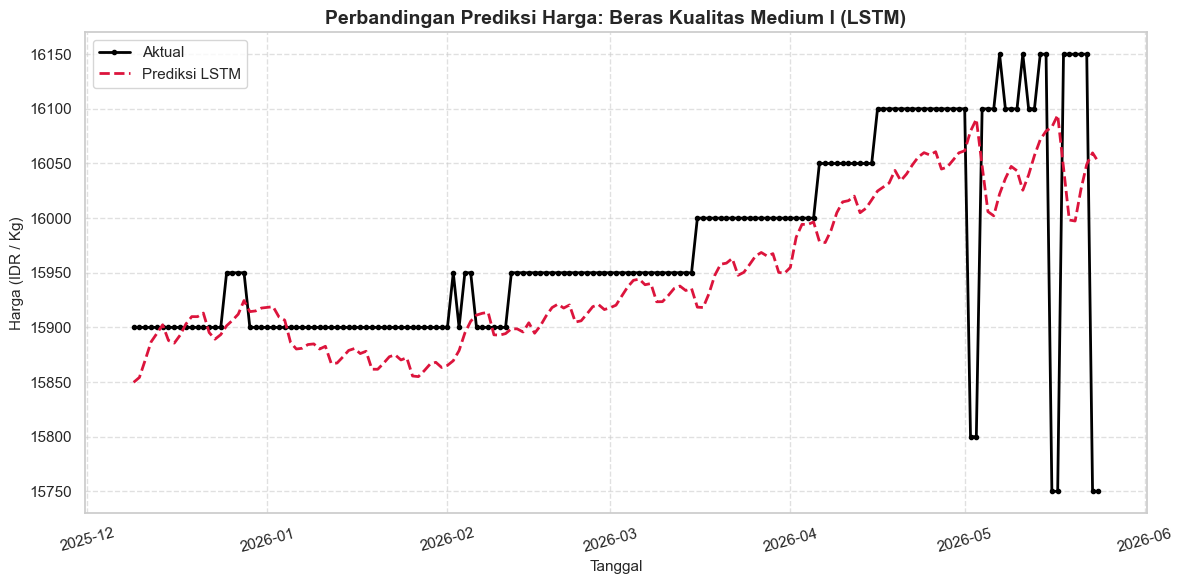

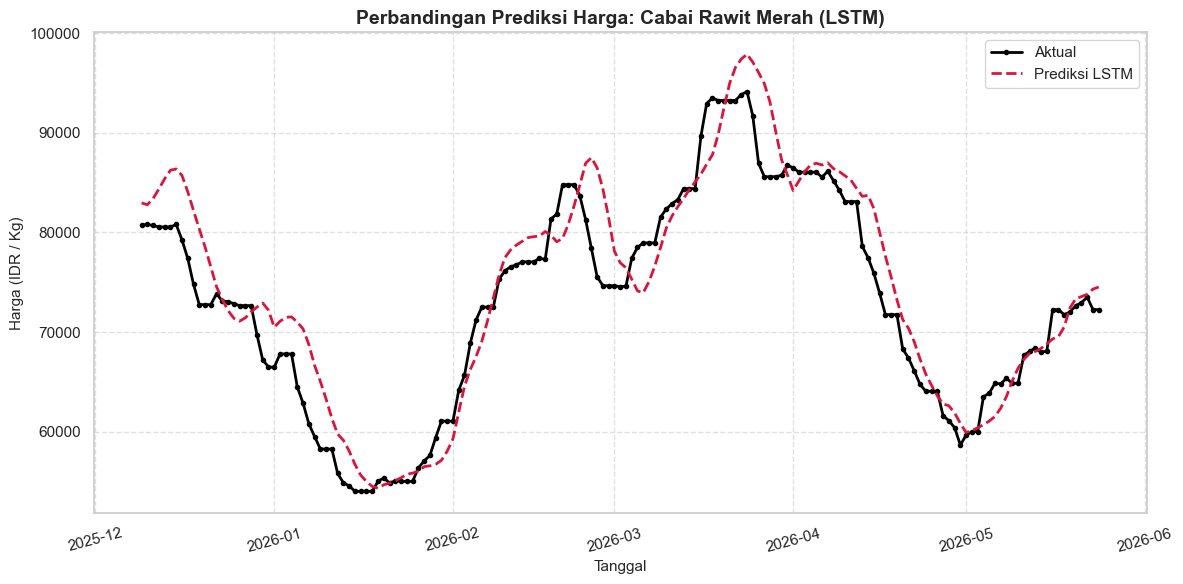

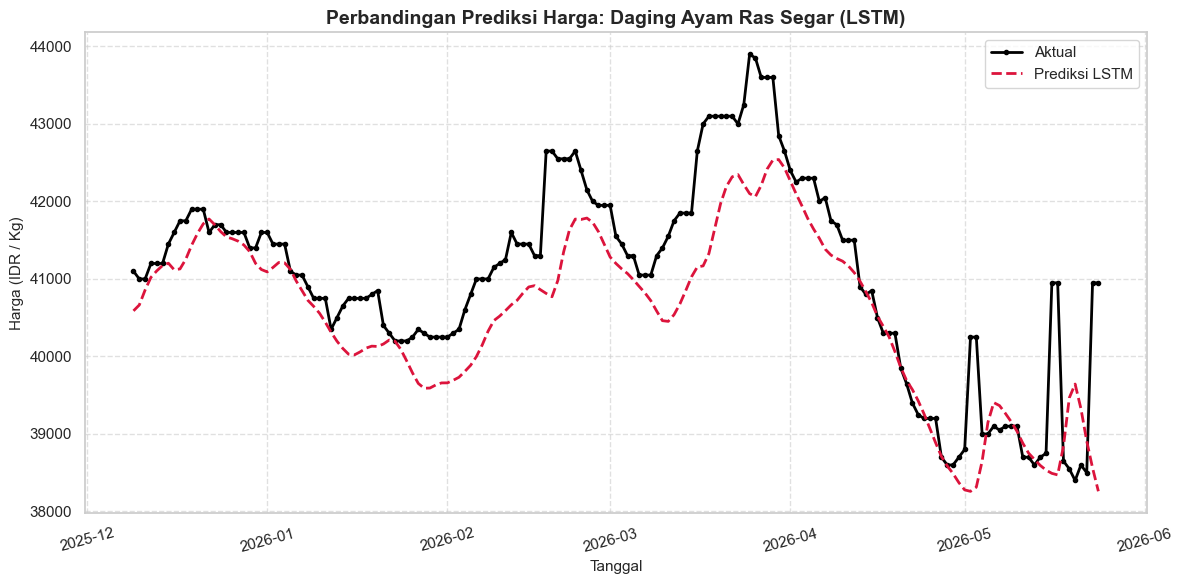

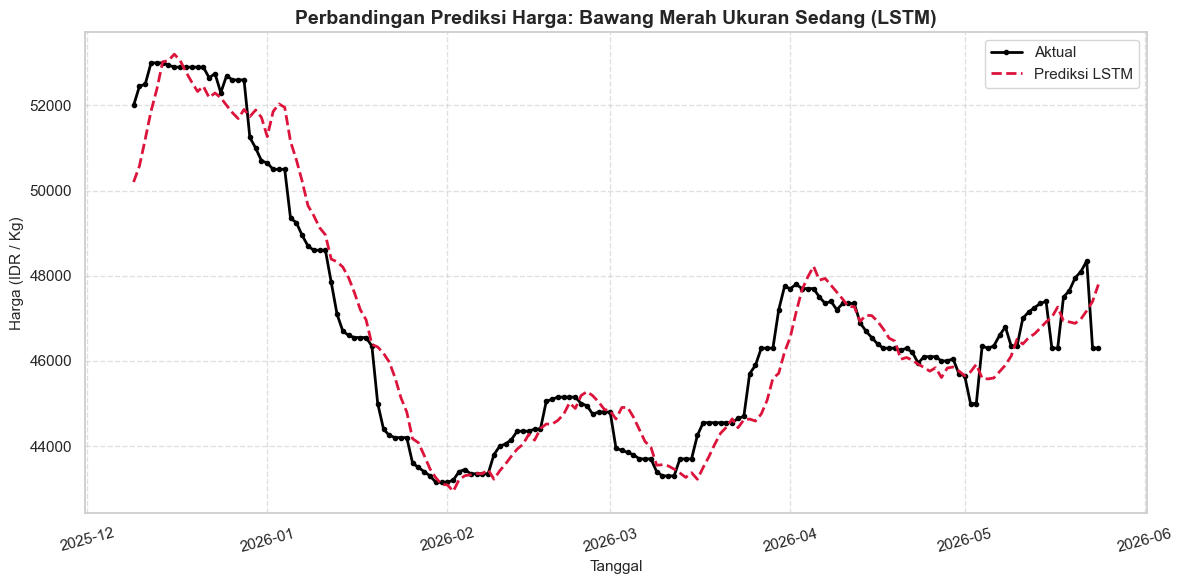

In [21]:
# Visualisasi Kurva Prediksi vs Aktual untuk 4 Subkategori Kunci
key_commodities = ["Beras Kualitas Medium I", "Cabai Rawit Merah", "Daging Ayam Ras Segar", "Bawang Merah Ukuran Sedang"]

for cat_name in key_commodities:
    if cat_name in predictions_dict:
        df_pred = predictions_dict[cat_name]
        
        plt.figure(figsize=(12, 6))
        plt.plot(df_pred.index, df_pred["Price"], label="Aktual", color="black", linewidth=2, marker='o', markersize=3)
        plt.plot(df_pred.index, df_pred["LSTM_Prediction"], label="Prediksi LSTM", color="crimson", linestyle="--", linewidth=2)
        
        plt.title(f"Perbandingan Prediksi Harga: {cat_name} (LSTM)", fontsize=14, fontweight='bold')
        plt.xlabel("Tanggal", fontsize=11)
        plt.ylabel("Harga (IDR / Kg)", fontsize=11)
        plt.legend(fontsize=11)
        plt.xticks(rotation=15)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Data untuk {cat_name} tidak ditemukan")

## Kesimpulan Analisis Eksplorasi LSTM
Berdasarkan hasil pemodelan deret waktu menggunakan LSTM berbasis PyTorch pada 21 subkategori komoditas pangan nasional:

1. **Kemampuan Menangkap Pola Non-linear & Volatilitas**:
   - Model LSTM menunjukkan performa yang sangat kuat di sebagian besar komoditas karena mampu memodelkan hubungan non-linear yang kompleks dan mengingat pola jangka pendek/menengah melalui memory cells.

2. **Peran Log-Transformation**:
   - Log-transformation secara signifikan menstabilkan varians harga pada komoditas volatil (seperti Cabai) dan mencegah terjadinya prediksi harga negatif pada model production-ready di Backend Arjuna. Hal ini juga meningkatkan performa $R^2$ secara menyeluruh terutama untuk komoditas dengan kenaikan harga/tren jangka panjang yang signifikan.

3. **Pentingnya Data Preprocessing & Training Best Practices**:
   - Penggunaan lag features (t-1, t-2, t-7) dan rolling mean/std terbukti krusial untuk melatih model sequence.
   - Pencegahan data leakage dengan fitting MinMaxScaler hanya pada set training serta inisiasi parameter model (Xavier/Orthogonal), gradient clipping, dan learning rate scheduler (ReduceLROnPlateau) terbukti sangat penting dalam memproduksi performa evaluasi pengujian yang stabil dan andal.